In [ ]:
!pip install yfinance pyts tensorflow scikit-learn pandas numpy matplotlib

In [2]:
# Librarires
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv2D, MaxPooling2D, Flatten
from pyts.image import GramianAngularField
from tensorflow.keras.backend import clear_session

## Step 1

### A)

/tmp/ipykernel_9749/3024680762.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


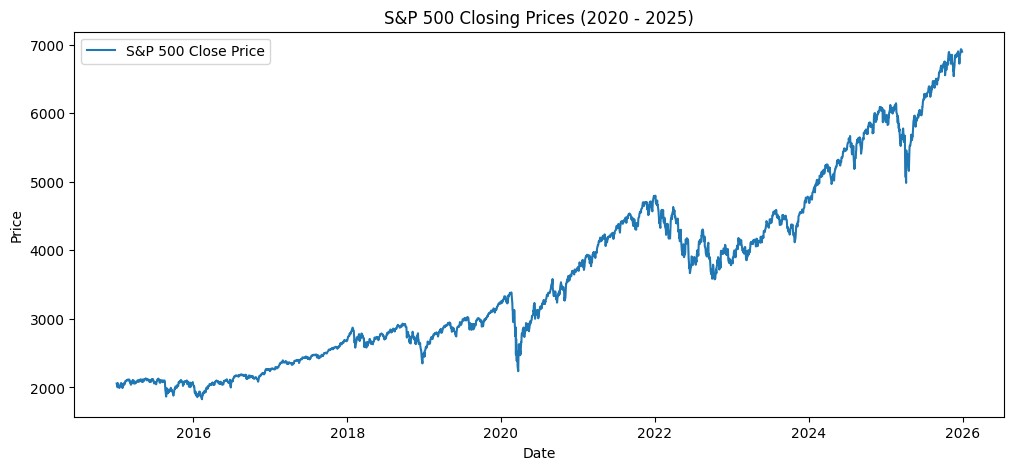

Total observations (must be < 2000): 2765
Price         Close       Return
Ticker        ^GSPC             
count   2765.000000  2764.000000
mean    3613.519475     0.000501
std     1325.819411     0.011283
min     1829.079956    -0.119841
25%     2485.739990    -0.003773
50%     3273.399902     0.000700
75%     4448.080078     0.005758
max     6932.049805     0.095154


In [5]:
# Download S&P 500 data
ticker = "^GSPC"
df = yf.download(ticker, start="2015-01-01", end="2025-12-31")
df = df[['Close']].copy()

# Daily returns
df['Return'] = df['Close'].pct_change()

# IMage
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label='S&P 500 Close Price')
plt.title('S&P 500 Closing Prices (2020 - 2025)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Textual description
print(f"Total observations (must be < 2000): {len(df)}")
print(df.describe())

### B)

In [ ]:
# ==========================================
# Step 1b: Predictive Model Labels & Leakage
# ==========================================
print("\n--- Step 1b: Building Labels with Leakage ---")
# LEAKAGE 1: Using a centered moving average for the target. 
# 'center=True' means the label for today is calculated using FUTURE days' returns.
df['Target'] = df['Return'].rolling(window=5, center=True).mean().shift(-1)

# Drop NaN values generated by rolling and shifting
df.dropna(inplace=True)

# LEAKAGE 2: Scaling the ENTIRE dataset before the train-test split.
# This leaks future distribution statistics (min/max) into the training set.
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

df['Scaled_Return'] = scaler_X.fit_transform(df[['Return']])
df['Scaled_Target'] = scaler_y.fit_transform(df[['Target']])

# Create sequences for DL models (Lookback window of 20 days)
lookback = 20
X, y = [], []
for i in range(lookback, len(df)):
    X.append(df['Scaled_Return'].iloc[i-lookback:i].values)
    y.append(df['Scaled_Target'].iloc[i])

X, y = np.array(X), np.array(y)

# ==========================================
# Step 1c: Train-Test Split and 2 DL Models
# ==========================================
print("\n--- Step 1c: DL Models (Single Split) ---")
# Single train-test split (80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = df.index[lookback + split:]

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# ------------------------------------------
# Model 1: LSTM
# ------------------------------------------
# Reshape X for LSTM [samples, time steps, features]
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(lookback, 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
print("Training LSTM...")
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, verbose=0)

# ------------------------------------------
# Model 2: CNN based on GAF
# ------------------------------------------
# Transform time series sequences into GAF images
gaf = GramianAngularField(image_size=lookback, method='summation')
X_train_gaf = gaf.fit_transform(X_train)
X_test_gaf = gaf.transform(X_test)

# Reshape for CNN [samples, height, width, channels]
X_train_cnn = X_train_gaf.reshape((X_train_gaf.shape[0], lookback, lookback, 1))
X_test_cnn = X_test_gaf.reshape((X_test_gaf.shape[0], lookback, lookback, 1))

cnn_model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(lookback, lookback, 1)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
print("Training GAF CNN...")
cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=32, verbose=0)

# ==========================================
# Step 1d: Backtesting Trading Strategies
# ==========================================
print("\n--- Step 1d: Backtesting ---")
# Generate predictions
lstm_preds = lstm_model.predict(X_test_lstm).flatten()
cnn_preds = cnn_model.predict(X_test_cnn).flatten()

# Inverse transform to get actual return scales (optional but good for thresholds)
lstm_preds_orig = scaler_y.inverse_transform(lstm_preds.reshape(-1, 1)).flatten()
cnn_preds_orig = scaler_y.inverse_transform(cnn_preds.reshape(-1, 1)).flatten()
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Simple Trading Strategy: 
# If predicted return > 0, go Long (1). If predicted return < 0, go Short (-1).
lstm_positions = np.where(lstm_preds_orig > 0, 1, -1)
cnn_positions = np.where(cnn_preds_orig > 0, 1, -1)

# Actual next day returns for the test period (from the original dataframe to avoid leaked target)
actual_returns_test = df['Return'].iloc[lookback + split:].values

# Calculate strategy returns
lstm_strategy_returns = lstm_positions * actual_returns_test
cnn_strategy_returns = cnn_positions * actual_returns_test

# Calculate cumulative returns for plotting
cum_market = np.cumprod(1 + actual_returns_test) - 1
cum_lstm = np.cumprod(1 + lstm_strategy_returns) - 1
cum_cnn = np.cumprod(1 + cnn_strategy_returns) - 1

# Plot Backtest Results
plt.figure(figsize=(12, 6))
plt.plot(dates_test, cum_market, label='Buy & Hold (Market)', color='black')
plt.plot(dates_test, cum_lstm, label='LSTM Strategy')
plt.plot(dates_test, cum_cnn, label='GAF CNN Strategy')
plt.title('Backtest Results: Cumulative Returns (Test Data)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

print("Step 1 complete. Proceed to Step 2 for walk-forward backtesting.")

In [ ]:


# ==========================================
# Helper Function: Walk-Forward Backtest
# ==========================================
def run_walk_forward(X_data, y_data, df_returns, lookback_window, train_size, test_size):
    """
    Performs a non-anchored walk-forward backtest.
    """
    num_samples = len(X_data)
    
    # Store overall predictions and actuals across all windows
    all_lstm_strat_returns = []
    all_cnn_strat_returns = []
    all_market_returns = []
    test_dates = []

    # Calculate how many full rolling windows we can do
    # Start index of the rolling window
    start_idx = 0
    
    while (start_idx + train_size + test_size) <= num_samples:
        print(f"Processing window: Train[{start_idx}:{start_idx+train_size}] Test[{start_idx+train_size}:{start_idx+train_size+test_size}]")
        
        # 1. Split Data for this window
        X_train_w = X_data[start_idx : start_idx + train_size]
        y_train_w = y_data[start_idx : start_idx + train_size]
        
        X_test_w = X_data[start_idx + train_size : start_idx + train_size + test_size]
        y_test_w = y_data[start_idx + train_size : start_idx + train_size + test_size]
        
        # Extract the actual market returns for the test period
        # Note: df_returns is the original dataframe's 'Return' column
        actual_test_returns = df_returns.iloc[lookback_window + start_idx + train_size : lookback_window + start_idx + train_size + test_size].values
        window_dates = df.index[lookback_window + start_idx + train_size : lookback_window + start_idx + train_size + test_size]
        
        # 2. Prepare Data for LSTM
        X_train_lstm = X_train_w.reshape((X_train_w.shape[0], X_train_w.shape[1], 1))
        X_test_lstm = X_test_w.reshape((X_test_w.shape[0], X_test_w.shape[1], 1))
        
        # 3. Prepare Data for CNN (GAF)
        gaf = GramianAngularField(image_size=X_data.shape[1], method='summation')
        X_train_gaf = gaf.fit_transform(X_train_w)
        X_test_gaf = gaf.transform(X_test_w)
        
        X_train_cnn = X_train_gaf.reshape((X_train_gaf.shape[0], X_train_gaf.shape[1], X_train_gaf.shape[2], 1))
        X_test_cnn = X_test_gaf.reshape((X_test_gaf.shape[0], X_test_gaf.shape[1], X_test_gaf.shape[2], 1))
        
        # 4. Build and Train LSTM
        clear_session() # Clear memory to avoid slowdowns in the loop
        lstm_model = Sequential([
            LSTM(50, activation='relu', input_shape=(X_data.shape[1], 1)),
            Dense(1)
        ])
        lstm_model.compile(optimizer='adam', loss='mse')
        lstm_model.fit(X_train_lstm, y_train_w, epochs=5, batch_size=32, verbose=0)
        
        # 5. Build and Train CNN
        cnn_model = Sequential([
            Conv2D(16, (3,3), activation='relu', input_shape=(X_data.shape[1], X_data.shape[1], 1)),
            MaxPooling2D(2,2),
            Flatten(),
            Dense(50, activation='relu'),
            Dense(1)
        ])
        cnn_model.compile(optimizer='adam', loss='mse')
        cnn_model.fit(X_train_cnn, y_train_w, epochs=5, batch_size=32, verbose=0)
        
        # 6. Predict and Calculate Strategy Returns
        lstm_preds = lstm_model.predict(X_test_lstm, verbose=0).flatten()
        cnn_preds = cnn_model.predict(X_test_cnn, verbose=0).flatten()
        
        # Transform back to original scale to check direction
        lstm_preds_orig = scaler_y.inverse_transform(lstm_preds.reshape(-1, 1)).flatten()
        cnn_preds_orig = scaler_y.inverse_transform(cnn_preds.reshape(-1, 1)).flatten()
        
        # Positions: 1 for Long, -1 for Short
        lstm_positions = np.where(lstm_preds_orig > 0, 1, -1)
        cnn_positions = np.where(cnn_preds_orig > 0, 1, -1)
        
        # Strategy Returns = Position * Actual Market Return
        lstm_returns = lstm_positions * actual_test_returns
        cnn_returns = cnn_positions * actual_test_returns
        
        # Append to overall results
        all_lstm_strat_returns.extend(lstm_returns)
        all_cnn_strat_returns.extend(cnn_returns)
        all_market_returns.extend(actual_test_returns)
        test_dates.extend(window_dates)
        
        # Slide the window forward (Non-anchored means we slide by the test size)
        start_idx += test_size

    # Calculate Cumulative Returns
    cum_market = np.cumprod(1 + np.array(all_market_returns)) - 1
    cum_lstm = np.cumprod(1 + np.array(all_lstm_strat_returns)) - 1
    cum_cnn = np.cumprod(1 + np.array(all_cnn_strat_returns)) - 1
    
    return test_dates, cum_market, cum_lstm, cum_cnn

# ==========================================
# Step 2a: 500 Train / 500 Test Split
# ==========================================
print("\n--- Step 2a: Walk-Forward (500 Train, 500 Test) ---")
dates_2a, market_2a, lstm_2a, cnn_2a = run_walk_forward(X, y, df['Return'], lookback, train_size=500, test_size=500)

plt.figure(figsize=(12, 5))
plt.plot(dates_2a, market_2a, label='Market (B&H)', color='black')
plt.plot(dates_2a, lstm_2a, label='LSTM')
plt.plot(dates_2a, cnn_2a, label='GAF CNN')
plt.title('Step 2a: Non-Anchored Walk Forward (500 Train / 500 Test)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

# ==========================================
# Step 2b: 500 Train / 100 Test Split
# ==========================================
print("\n--- Step 2b: Walk-Forward (500 Train, 100 Test) ---")
dates_2b, market_2b, lstm_2b, cnn_2b = run_walk_forward(X, y, df['Return'], lookback, train_size=500, test_size=100)

plt.figure(figsize=(12, 5))
plt.plot(dates_2b, market_2b, label='Market (B&H)', color='black')
plt.plot(dates_2b, lstm_2b, label='LSTM')
plt.plot(dates_2b, cnn_2b, label='GAF CNN')
plt.title('Step 2b: Non-Anchored Walk Forward (500 Train / 100 Test)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

print("\nCode execution for Step 2 complete.")